# Week 2: Exploratory Data Analysis (EDA)
**Author:** Krishna  
**Goal:** Understand the data, visualise it, and create a subject‑wise train/test split.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
project_path = '/content/drive/MyDrive/ParkinsonsProject/ParkinsonsDetection'
os.chdir(project_path)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


## Load the Dataset

In [2]:
df = pd.read_csv('data/raw/parkinsons.csv')
print("Data shape:", df.shape)
df.head()

Data shape: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## Basic Information
- Check data types, missing values, and summary statistics.

In [3]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary statistics:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

## Class Balance
Examine the target variable `status` (1 = Parkinson's, 0 = healthy).

In [4]:
print(df['status'].value_counts())
print("Percentage:\n", df['status'].value_counts(normalize=True) * 100)

status
1    147
0     48
Name: count, dtype: int64
Percentage:
 status
1    75.384615
0    24.615385
Name: proportion, dtype: float64


## Create Subject IDs
The `name` column contains codes like `phon_R01_S01_1`. We extract the subject part (e.g., `phon_R01_S01`) to group recordings per subject.

In [5]:
df['subject_id'] = df['name'].apply(lambda x: '_'.join(x.split('_')[:3]))
print("Number of unique subjects:", df['subject_id'].nunique())
df[['name','subject_id']].head()

Number of unique subjects: 32


,name,subject_id
0,phon_R01_S01_1,phon_R01_S01
1,phon_R01_S01_2,phon_R01_S01
2,phon_R01_S01_3,phon_R01_S01
3,phon_R01_S01_4,phon_R01_S01
4,phon_R01_S01_5,phon_R01_S01


## Visualise Feature Distributions
Plot histograms for a few key features.

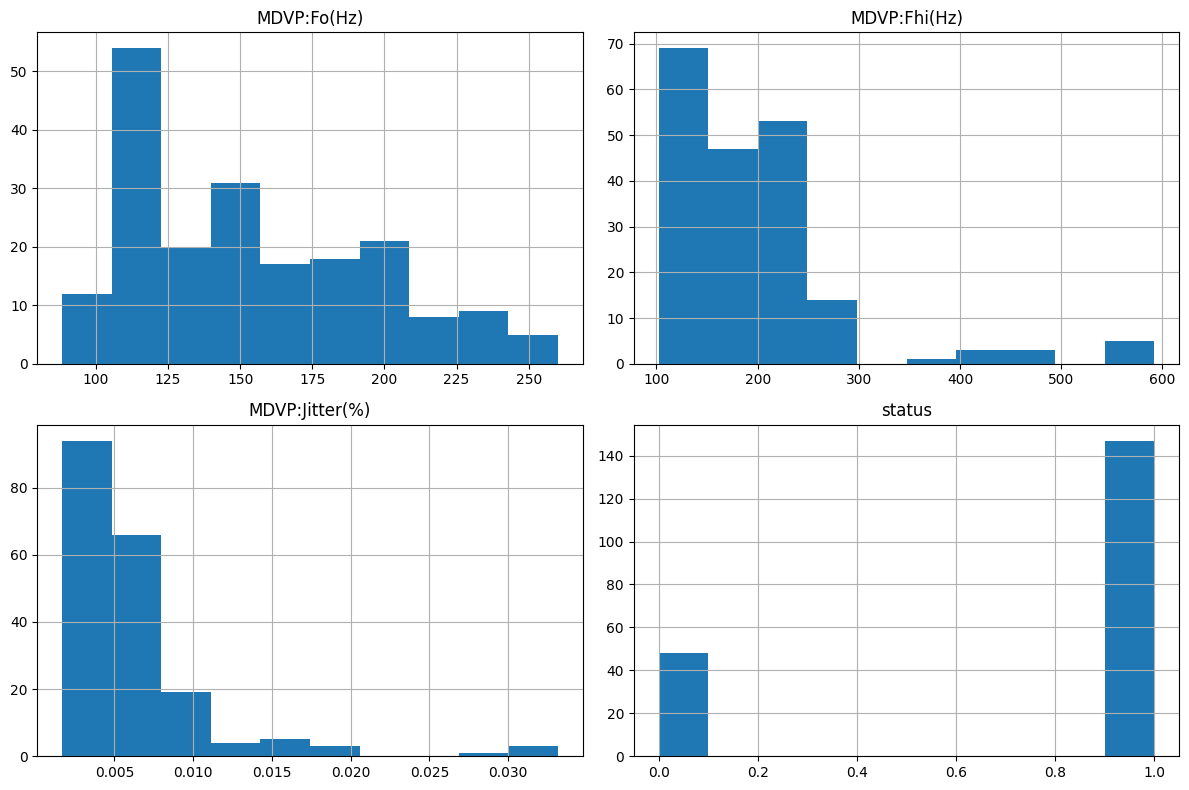

In [6]:
features_to_plot = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Jitter(%)', 'status']
df[features_to_plot].hist(figsize=(12,8))
plt.tight_layout()
plt.savefig('reports/figures/histograms.png')
plt.show()

## Boxplots by Class
Compare distributions between healthy and Parkinson's groups.

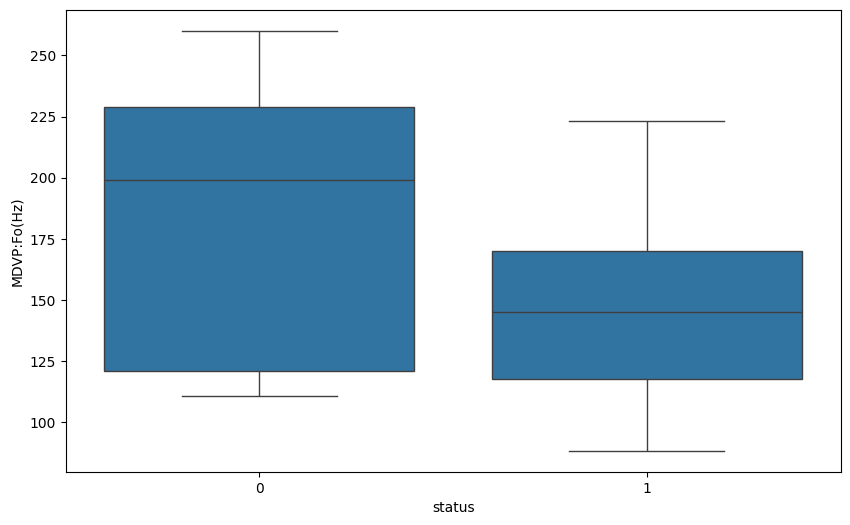

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(x='status', y='MDVP:Fo(Hz)', data=df)
plt.savefig('reports/figures/boxplot_f0.png')
plt.show()

## Correlation Matrix
Visualise correlations among numeric features (excluding `name` and `subject_id`).

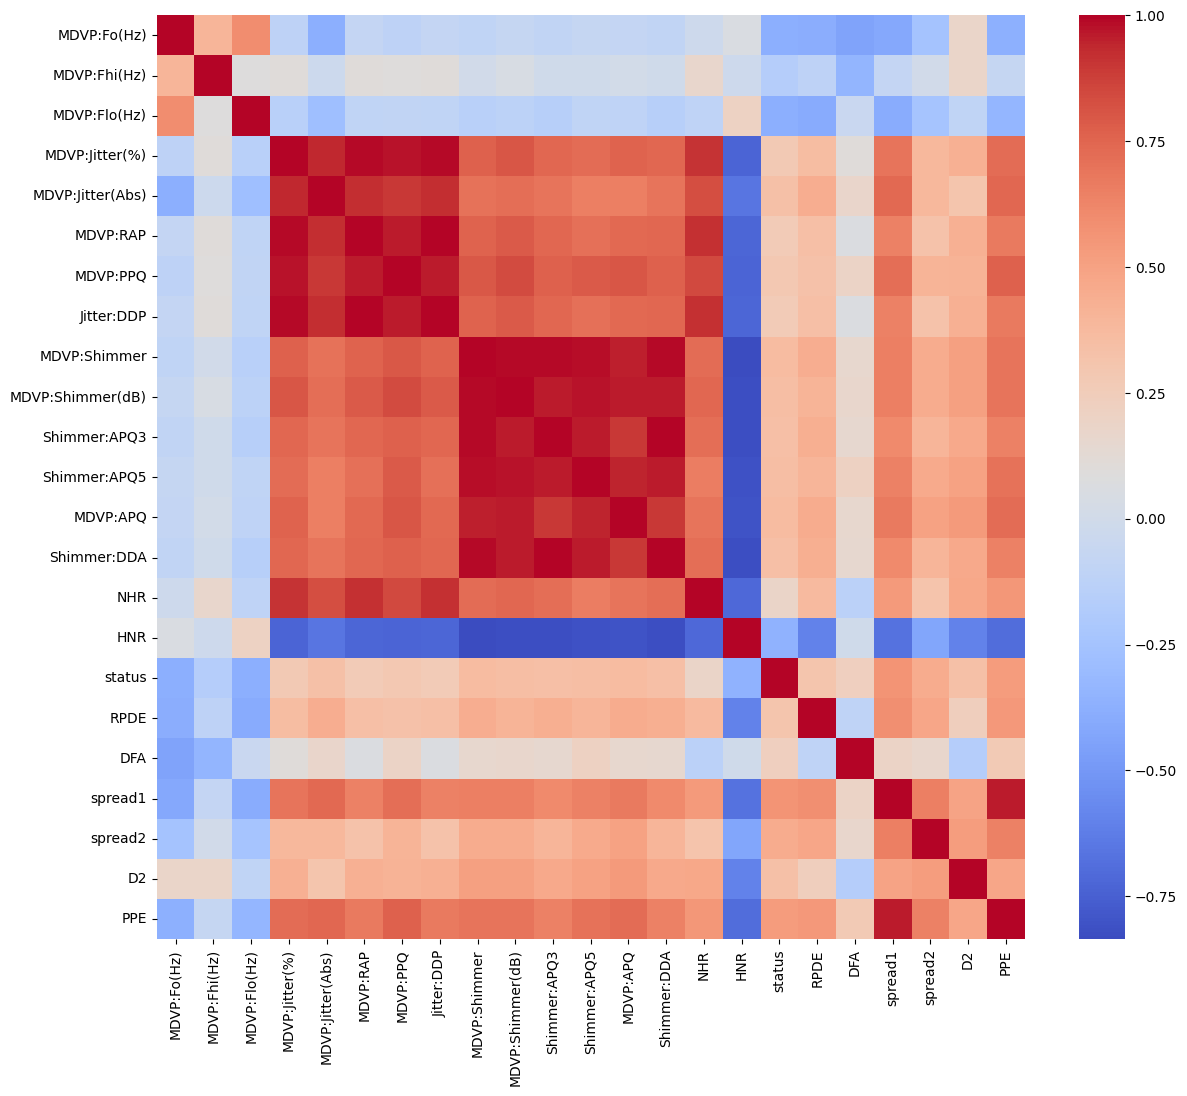

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.savefig('reports/figures/correlation_heatmap.png')
plt.show()

## Subject‑wise Train/Test Split
Use `GroupShuffleSplit` to ensure all recordings of a subject stay in the same set.

In [9]:
from sklearn.model_selection import GroupShuffleSplit

X = df.drop(['status', 'name', 'subject_id'], axis=1)   # features only
y = df['status']
groups = df['subject_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

# Save indices for later use
np.save('data/processed/train_indices.npy', train_idx)
np.save('data/processed/test_indices.npy', test_idx)

print(f"Train size: {len(train_idx)}, Test size: {len(test_idx)}")
print("Indices saved to data/processed/")

Train size: 134, Test size: 61
Indices saved to data/processed/


## Done
Completed EDA and saved the subject‑wise split indices.  
Proceed to Week 3 (Preprocessing).